In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

col_names = ["unit_id", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

train_df = pd.read_csv("../../data/equipment_failure/CMaps/train_FD001.txt",
                        sep=r"\s+", header=None, names=col_names, engine="python")
test_df = pd.read_csv("../../data/equipment_failure/CMaps/test_FD001.txt",
                       sep=r"\s+", header=None, names=col_names, engine="python")
rul_df = pd.read_csv("../../data/equipment_failure/CMaps/RUL_FD001.txt",
                      header=None, names=["RUL"])

train_df = train_df.dropna(axis=1)
test_df = test_df.dropna(axis=1)

train_df["unit_id"] = train_df["unit_id"].astype(int)
train_df["cycle"] = train_df["cycle"].astype(int)
test_df["unit_id"] = test_df["unit_id"].astype(int)
test_df["cycle"] = test_df["cycle"].astype(int)

print("DATASET: NASA CMAPSS FD001 — Turbofan Engine Degradation")
print()
print(f"Train shape     : {train_df.shape}")
print(f"Test shape      : {test_df.shape}")
print(f"Train engines   : {train_df['unit_id'].nunique()}")
print(f"Test engines    : {test_df['unit_id'].nunique()}")
print(f"Max cycles train: {train_df['cycle'].max()}")
print()
print("Columns:", list(train_df.columns))
print()
print("Sample data:")
print(train_df.head(3))

DATASET: NASA CMAPSS FD001 — Turbofan Engine Degradation

Train shape     : (20631, 26)
Test shape      : (13096, 26)
Train engines   : 100
Test engines    : 100
Max cycles train: 362

Columns: ['unit_id', 'cycle', 'op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']

Sample data:
   unit_id  cycle     op1     op2      op3       s1       s2        s3  \
0        1      1 -0.0007 -0.0004 100.0000 518.6700 641.8200 1589.7000   
1        1      2  0.0019 -0.0003 100.0000 518.6700 642.1500 1591.8200   
2        1      3 -0.0043  0.0003 100.0000 518.6700 642.3500 1587.9900   

         s4      s5  ...      s12       s13       s14    s15    s16  s17  \
0 1400.6000 14.6200  ... 521.6600 2388.0200 8138.6200 8.4195 0.0300  392   
1 1403.1400 14.6200  ... 522.2800 2388.0700 8131.4900 8.4318 0.0300  392   
2 1404.2000 14.6200  ... 522.4200 2388.0300 8133.2300 8.4178 0.0300  390   

    s18   

In [8]:
# Understand the Data
print("DATA UNDERSTANDING")
print()
print("This dataset simulates turbofan engine degradation.")
print("Each engine starts healthy and degrades until failure.")
print("Goal: Predict Remaining Useful Life (RUL) before failure.")
print()
print("Columns description:")
print("  unit_id  : Engine ID (1-100 engines in train)")
print("  cycle    : Operational cycle number (time step)")
print("  op1-op3  : Operational settings (flight conditions)")
print("  s1-s21   : Sensor measurements (temperature, pressure, speed...)")
print()

print("Cycles per engine (train):")
cycles_per_engine = train_df.groupby("unit_id")["cycle"].max()
print(f"  Min cycles  : {cycles_per_engine.min()}")
print(f"  Max cycles  : {cycles_per_engine.max()}")
print(f"  Mean cycles : {cycles_per_engine.mean():.1f}")
print(f"  Std cycles  : {cycles_per_engine.std():.1f}")
print()

print("Missing values:", train_df.isnull().sum().sum())
print()

print("Operational settings distribution:")
for col in ["op1", "op2", "op3"]:
    print(f"  {col}: unique values = {train_df[col].nunique()} | range = [{train_df[col].min():.3f}, {train_df[col].max():.3f}]")

DATA UNDERSTANDING

This dataset simulates turbofan engine degradation.
Each engine starts healthy and degrades until failure.
Goal: Predict Remaining Useful Life (RUL) before failure.

Columns description:
  unit_id  : Engine ID (1-100 engines in train)
  cycle    : Operational cycle number (time step)
  op1-op3  : Operational settings (flight conditions)
  s1-s21   : Sensor measurements (temperature, pressure, speed...)

Cycles per engine (train):
  Min cycles  : 128
  Max cycles  : 362
  Mean cycles : 206.3
  Std cycles  : 46.3

Missing values: 0

Operational settings distribution:
  op1: unique values = 158 | range = [-0.009, 0.009]
  op2: unique values = 13 | range = [-0.001, 0.001]
  op3: unique values = 1 | range = [100.000, 100.000]


CREATING REMAINING USEFUL LIFE (RUL) TARGET

RUL range    : 0 to 361
Mean RUL     : 107.8
Median RUL   : 103.0

RUL clipped at 125 cycles (industry standard)
Reason: Early in engine life, exact RUL does not matter.
We only care about predicting accurately when failure is near.



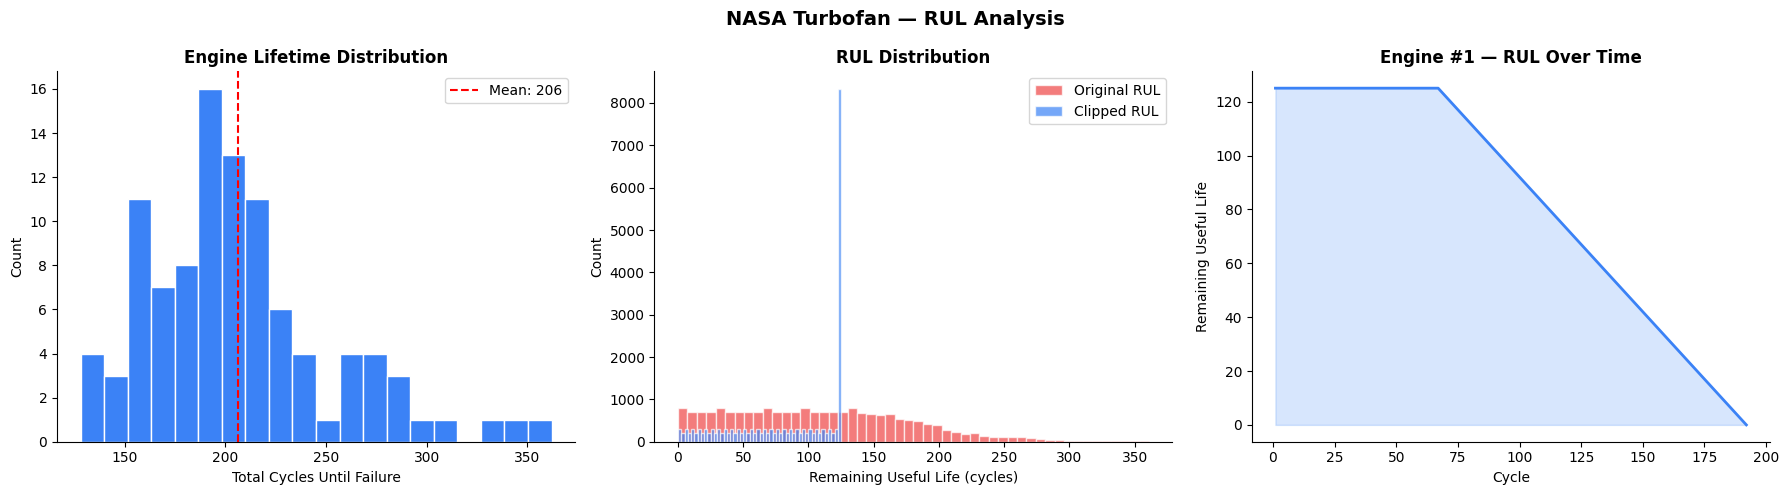

In [9]:
# Create RUL Target Variable
print("CREATING REMAINING USEFUL LIFE (RUL) TARGET")
print()

max_cycles = train_df.groupby("unit_id")["cycle"].max().reset_index()
max_cycles.columns = ["unit_id", "max_cycle"]
train_df = train_df.merge(max_cycles, on="unit_id")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df = train_df.drop(columns=["max_cycle"])

print(f"RUL range    : {train_df['RUL'].min()} to {train_df['RUL'].max()}")
print(f"Mean RUL     : {train_df['RUL'].mean():.1f}")
print(f"Median RUL   : {train_df['RUL'].median():.1f}")
print()

CLIP_RUL = 125
train_df["RUL_clipped"] = train_df["RUL"].clip(upper=CLIP_RUL)
print(f"RUL clipped at {CLIP_RUL} cycles (industry standard)")
print("Reason: Early in engine life, exact RUL does not matter.")
print("We only care about predicting accurately when failure is near.")
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(cycles_per_engine.values, bins=20, color="#3b82f6", edgecolor="white")
axes[0].set_title("Engine Lifetime Distribution", fontweight="bold")
axes[0].set_xlabel("Total Cycles Until Failure")
axes[0].set_ylabel("Count")
axes[0].axvline(cycles_per_engine.mean(), color="red", linestyle="--", label=f"Mean: {cycles_per_engine.mean():.0f}")
axes[0].legend()

axes[1].hist(train_df["RUL"], bins=50, color="#ef4444", edgecolor="white", alpha=0.7, label="Original RUL")
axes[1].hist(train_df["RUL_clipped"], bins=50, color="#3b82f6", edgecolor="white", alpha=0.7, label="Clipped RUL")
axes[1].set_title("RUL Distribution", fontweight="bold")
axes[1].set_xlabel("Remaining Useful Life (cycles)")
axes[1].set_ylabel("Count")
axes[1].legend()

sample_engine = train_df[train_df["unit_id"] == 1]
axes[2].plot(sample_engine["cycle"], sample_engine["RUL_clipped"], color="#3b82f6", linewidth=2)
axes[2].set_title("Engine #1 — RUL Over Time", fontweight="bold")
axes[2].set_xlabel("Cycle")
axes[2].set_ylabel("Remaining Useful Life")
axes[2].fill_between(sample_engine["cycle"], sample_engine["RUL_clipped"], alpha=0.2, color="#3b82f6")

plt.suptitle("NASA Turbofan — RUL Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/equipment_failure/rul_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

SENSOR ANALYSIS

Sensor variance (low variance = not useful for prediction):
  Useful sensors   : ['s9', 's14', 's4', 's3', 's17', 's7', 's12', 's2', 's11', 's20', 's21', 's13', 's8', 's15']
  Low variance     : ['s6', 's5', 's16', 's10', 's18', 's19', 's1'] (will be dropped)

Sensor correlation with RUL (top signals):
s11   0.6962
s4    0.6789
s12   0.6720
s7    0.6572
s15   0.6427
s21   0.6357
s20   0.6294
s2    0.6065
s17   0.6062
s3    0.5845
Name: RUL, dtype: float64


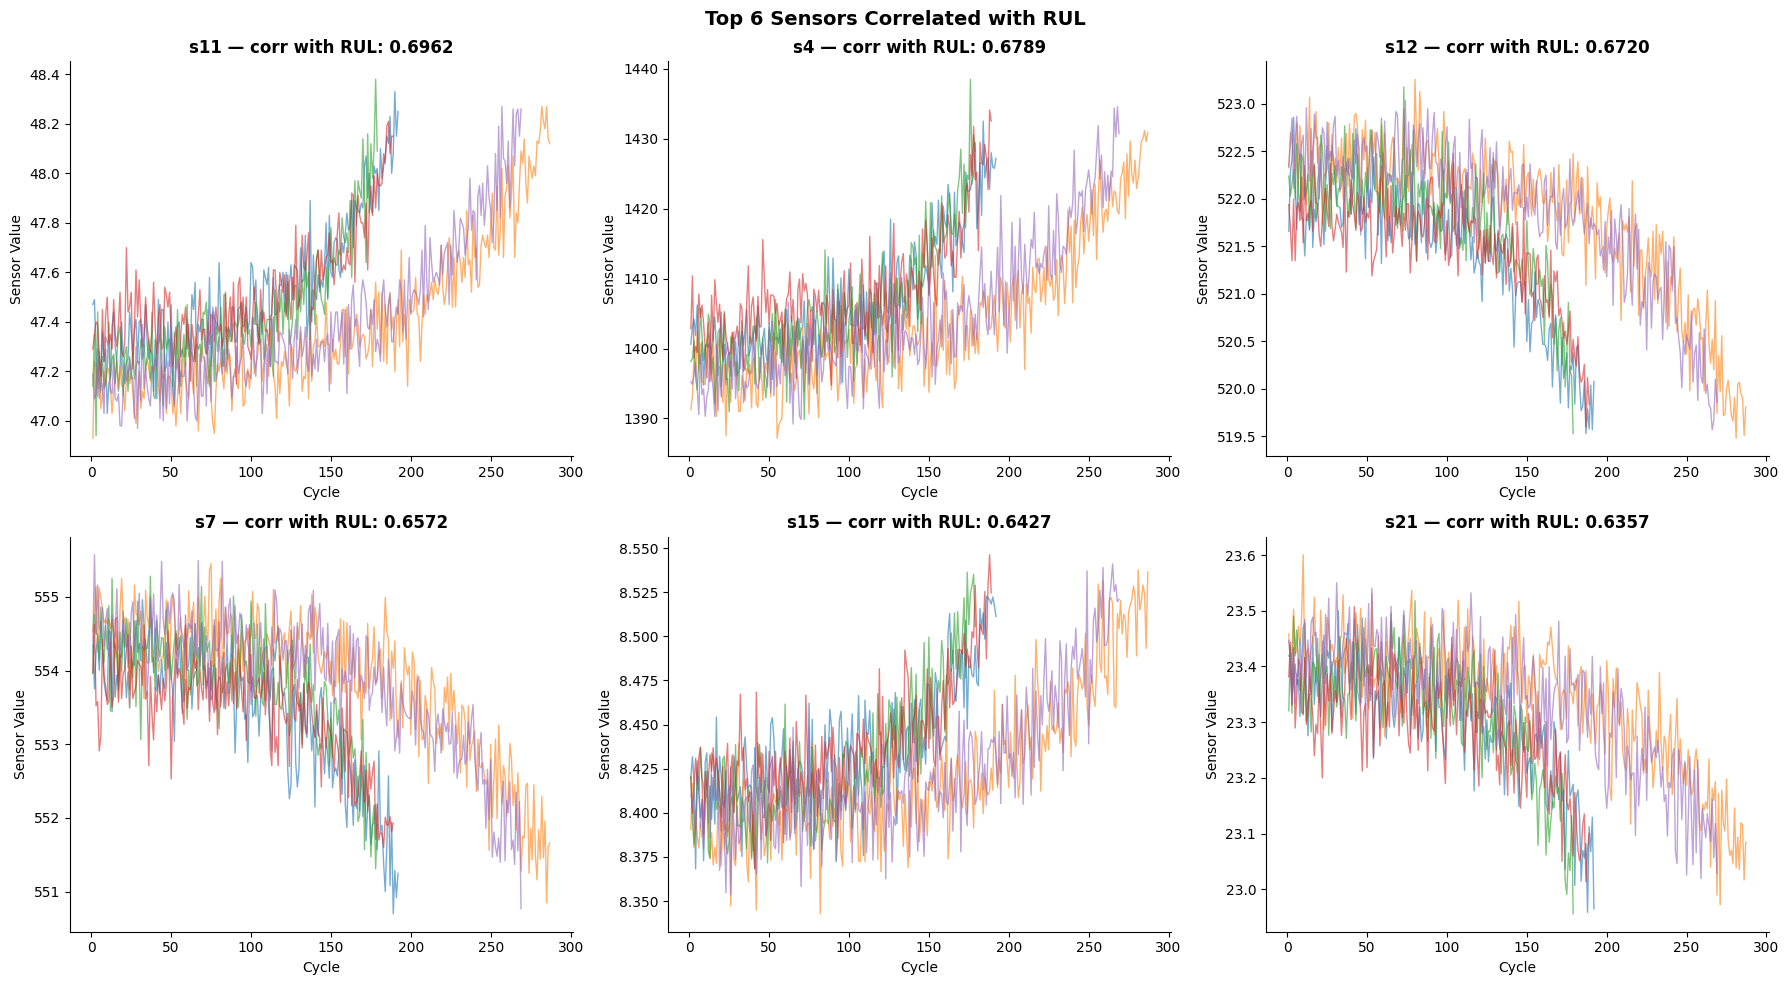

In [10]:
# Sensor Analysis
print("SENSOR ANALYSIS")
print()

sensor_cols = [f"s{i}" for i in range(1, 22) if f"s{i}" in train_df.columns]

print("Sensor variance (low variance = not useful for prediction):")
sensor_std = train_df[sensor_cols].std().sort_values(ascending=False)
low_var_sensors = sensor_std[sensor_std < 0.01].index.tolist()
useful_sensors = sensor_std[sensor_std >= 0.01].index.tolist()
print(f"  Useful sensors   : {useful_sensors}")
print(f"  Low variance     : {low_var_sensors} (will be dropped)")
print()

print("Sensor correlation with RUL (top signals):")
correlations = train_df[sensor_cols + ["RUL"]].corr()["RUL"].drop("RUL").abs().sort_values(ascending=False)
print(correlations.head(10).round(4))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

top_sensors = correlations.head(6).index.tolist()
for i, sensor in enumerate(top_sensors):
    sample = train_df[train_df["unit_id"].isin([1, 2, 3, 4, 5])]
    for uid in [1, 2, 3, 4, 5]:
        eng = sample[sample["unit_id"] == uid]
        axes[i].plot(eng["cycle"], eng[sensor], alpha=0.6, linewidth=1)
    axes[i].set_title(f"{sensor} — corr with RUL: {correlations[sensor]:.4f}", fontweight="bold")
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel("Sensor Value")

plt.suptitle("Top 6 Sensors Correlated with RUL", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/equipment_failure/sensor_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

DEGRADATION PATTERN ANALYSIS

Analyzing how sensors degrade as engine approaches failure...

  s11: increases by 1.2% from healthy to failure
  s4: increases by 1.3% from healthy to failure
  s12: decreases by 0.3% from healthy to failure
  s7: decreases by 0.3% from healthy to failure


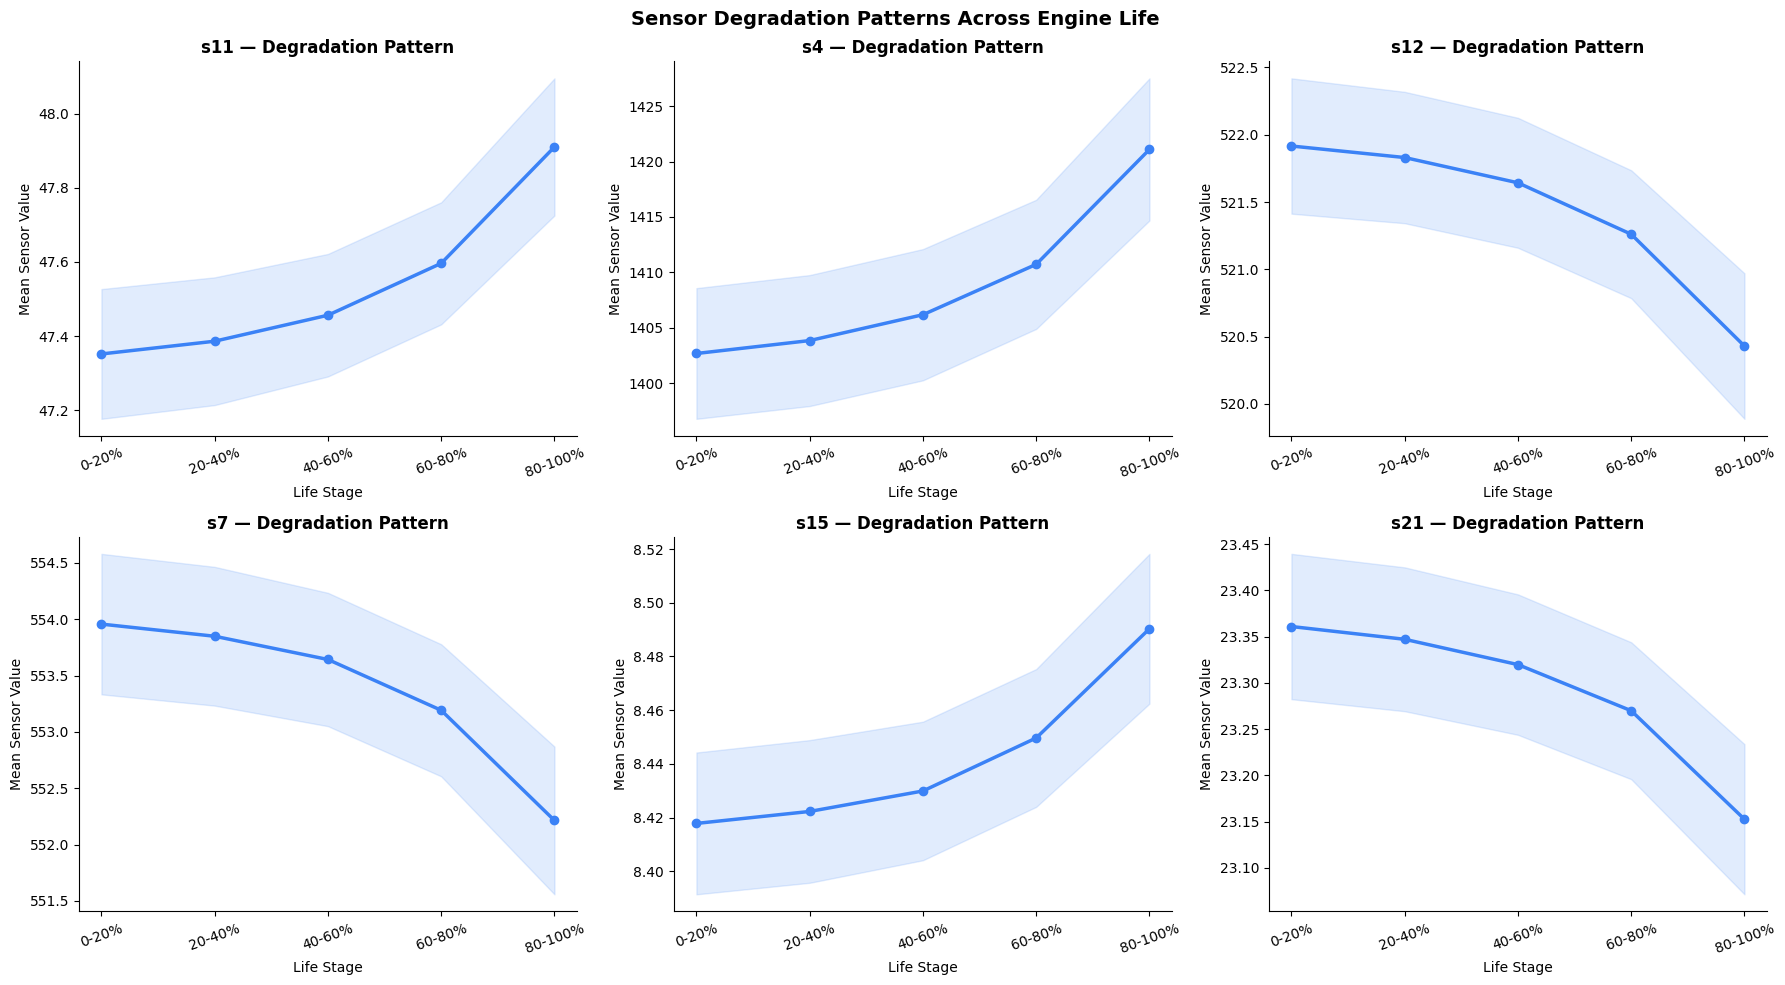


Useful sensors for modeling: ['s9', 's14', 's4', 's3', 's17', 's7', 's12', 's2', 's11', 's20', 's21', 's13', 's8', 's15']
Total useful sensors: 14


In [11]:
# Degradation Pattern Analysis
print("DEGRADATION PATTERN ANALYSIS")
print()

print("Analyzing how sensors degrade as engine approaches failure...")
print()

life_pct_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
train_df["life_pct"] = train_df["cycle"] / train_df.groupby("unit_id")["cycle"].transform("max")
train_df["life_stage"] = pd.cut(train_df["life_pct"], bins=life_pct_bins,
                                 labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"])

for sensor in top_sensors[:4]:
    stage_means = train_df.groupby("life_stage", observed=True)[sensor].mean()
    change = ((stage_means.iloc[-1] - stage_means.iloc[0]) / abs(stage_means.iloc[0] + 1e-10)) * 100
    direction = "increases" if change > 0 else "decreases"
    print(f"  {sensor}: {direction} by {abs(change):.1f}% from healthy to failure")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    stage_means = train_df.groupby("life_stage", observed=True)[sensor].mean()
    stage_std = train_df.groupby("life_stage", observed=True)[sensor].std()
    x = range(len(stage_means))
    axes[i].plot(x, stage_means.values, color="#3b82f6", linewidth=2.5, marker="o")
    axes[i].fill_between(x, stage_means - stage_std, stage_means + stage_std, alpha=0.15, color="#3b82f6")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(stage_means.index, rotation=20)
    axes[i].set_title(f"{sensor} — Degradation Pattern", fontweight="bold")
    axes[i].set_xlabel("Life Stage")
    axes[i].set_ylabel("Mean Sensor Value")

plt.suptitle("Sensor Degradation Patterns Across Engine Life", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/equipment_failure/degradation_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print(f"Useful sensors for modeling: {useful_sensors}")
print(f"Total useful sensors: {len(useful_sensors)}")

In [13]:
# Save Cleaned Data and Key Findings
print("KEY FINDINGS")
print()
print(f"1. Dataset          : 100 engines, {train_df['unit_id'].nunique()} unique, avg {cycles_per_engine.mean():.0f} cycles to failure")
print(f"2. RUL range        : 0 to {train_df['RUL'].max()} cycles | clipped at {CLIP_RUL}")
print(f"3. Useful sensors   : {len(useful_sensors)} out of {len(sensor_cols)} (dropped {len(low_var_sensors)} constant sensors)")
print(f"4. Best sensor      : {correlations.index[0]} with RUL correlation {correlations.iloc[0]:.4f}")
print(f"5. Degradation      : Clear monotonic trends visible in top sensors near failure")
print()
print("Strategy for modeling:")
print("  This is a REGRESSION problem — predict exact RUL value")
print("  Also frame as CLASSIFICATION — predict if failure within N cycles")
print("  Use rolling window features to capture temporal degradation patterns")
print("  XGBoost Regressor + Random Forest Regressor + threshold-based classifier")

import os
os.makedirs("../../data/equipment_failure", exist_ok=True)

train_df.to_csv("../../data/equipment_failure/train_cleaned.csv", index=False)

meta = {
    "useful_sensors": useful_sensors,
    "low_var_sensors": low_var_sensors,
    "clip_rul": CLIP_RUL,
    "n_engines_train": int(train_df["unit_id"].nunique()),
    "top_sensors": top_sensors
}
import json
with open("../../data/equipment_failure/meta.json", "w") as f:
    json.dump(meta, f, indent=4)

print()


KEY FINDINGS

1. Dataset          : 100 engines, 100 unique, avg 206 cycles to failure
2. RUL range        : 0 to 361 cycles | clipped at 125
3. Useful sensors   : 14 out of 21 (dropped 7 constant sensors)
4. Best sensor      : s11 with RUL correlation 0.6962
5. Degradation      : Clear monotonic trends visible in top sensors near failure

Strategy for modeling:
  This is a REGRESSION problem — predict exact RUL value
  Also frame as CLASSIFICATION — predict if failure within N cycles
  Use rolling window features to capture temporal degradation patterns
  XGBoost Regressor + Random Forest Regressor + threshold-based classifier

